<a href="https://colab.research.google.com/github/Nevethawei/my-first-code/blob/main/Face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (1140, 50, 37)
Number of classes: 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,517 (877.02 KB)

 Trainable params: 224,517 (877.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.4306 - loss: 1.5159 - val_accuracy: 0.4649 - val_loss: 1.4193
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4422 - loss: 1.4688 - val_accuracy: 0.4649 - val_loss: 1.4366
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.4795 - loss: 1.4275 - val_accuracy: 0.4649 - val_loss: 1.4016
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.4726 - loss: 1.4225 - val_accuracy: 0.4649 - val_loss: 1.4058
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4591 - loss: 1.4292 - val_accuracy: 0.4649 - val_loss: 1.4080
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4636 - loss: 1.4262 - val_accuracy: 0.4649 - val_loss: 1.4111
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.4825 - loss: 1.4020 - val_accuracy: 0.4649 - val_loss: 1.4207
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4488 - loss: 1.4397 - val_accuracy: 0.4649 - 

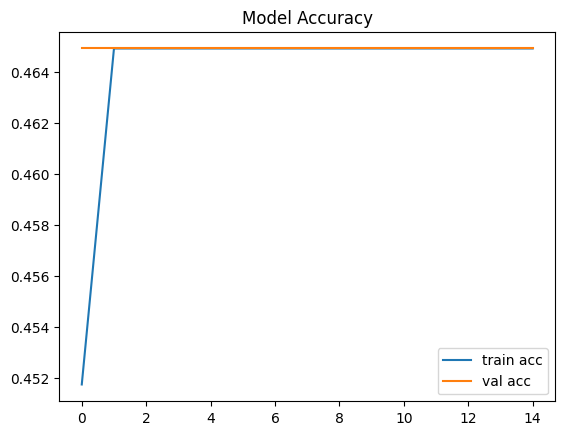

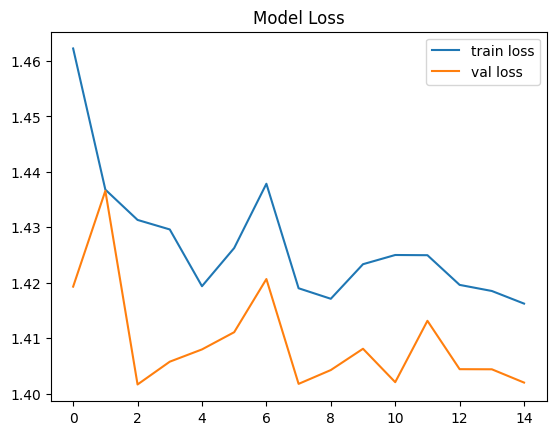

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


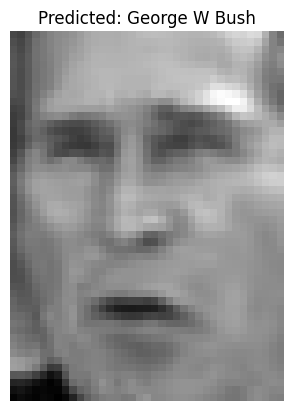

In [ ]:
# face_recognition_cnn.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, utils

# 1. Load Inbuilt LFW Dataset
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
X = lfw_people.images   # shape: (n_samples, h, w)
y = lfw_people.target
target_names = lfw_people.target_names
h, w = lfw_people.images[0].shape

print("Dataset shape:", X.shape)
print("Number of classes:", len(target_names))

# 2. Preprocess Data
X = X / 255.0                       # Normalize images
X = X.reshape(X.shape[0], h, w, 1)  # Add channel dimension
y_cat = utils.to_categorical(y, len(target_names))  # One-hot encode

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

# 3. Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(h, w, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. Train Model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# 5. Evaluate Model
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

# 6. Plot Accuracy & Loss
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Model Loss")
plt.show()

# 7. Test Prediction on Random Image
idx = np.random.randint(0, len(X_test))
test_img = X_test[idx].reshape(1, h, w, 1)

prediction = model.predict(test_img)
pred_class = np.argmax(prediction)

plt.imshow(X_test[idx].reshape(h, w), cmap='gray')
plt.title(f"Predicted: {target_names[pred_class]}")
plt.axis('off')
plt.show()

Dataset shape: (1140, 50, 37)
Classes: ['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


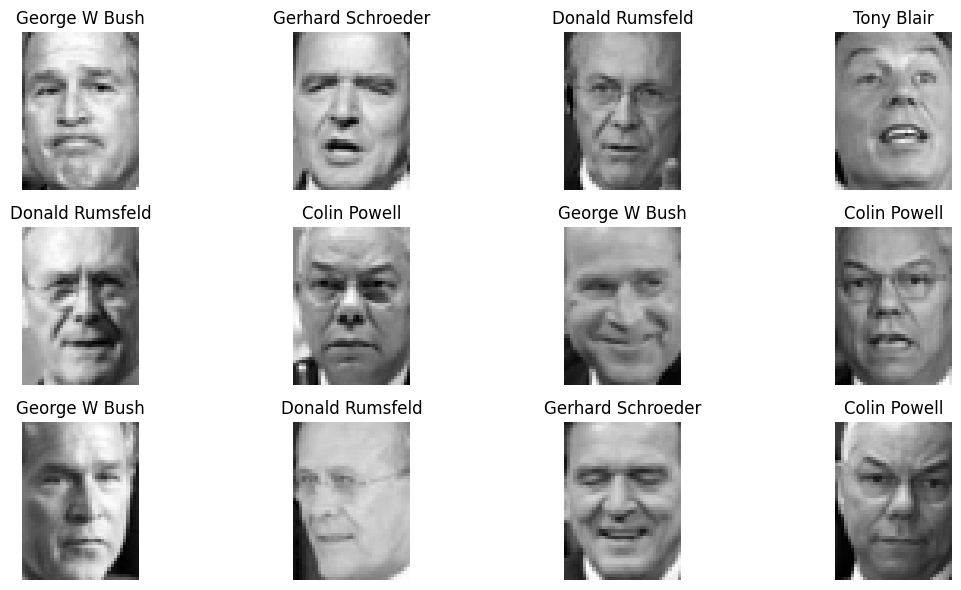

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

# Load LFW dataset (only people with at least 100 images)
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)

X = lfw_people.images      # images
y = lfw_people.target      # labels (numbers)
names = lfw_people.target_names  # person names

print("Dataset shape:", X.shape)
print("Classes:", names)

# Show first 12 images with labels
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()
